# Customer churn Prediction

## 1. Import libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Data Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Model Evaluation

from sklearn.metrics import (mean_squared_error, confusion_matrix, accuracy_score, classification_report)


## 2. Load Dataset

In [2]:
df=pd.read_csv("customer_churn.csv")

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 3. Understand the Data

### 3.1 Dataset Shape

In [4]:
df.shape

(7043, 21)

### 3.2 Preview the Dataset

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.3 Dataset information

In [6]:
df. info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 3.4 Missing Values

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3.5 Duplicate Records

In [8]:
df.duplicated().sum()

0

### 3.6 Summary Statistics

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Cleaning

### 4.1 Convert Data Types

In [10]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors="coerce")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 4.2 Handle Missing Values

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 4.3 Check Duplicate Records

In [15]:
df.duplicated().sum()

0

### 4.4 Remove Unnecessary Columns

In [16]:
df=df.drop(['customerID'],axis=1)

In [17]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## 5. Data Manipulation

### 5.1 Customer Filtering

In [18]:
senior_male_electronic=df[(df["gender"]=="Male") & (df["SeniorCitizen"]==1) & (df["PaymentMethod"]=="Electronic check")]

In [19]:
senior_male_electronic.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,Male,1,No,No,1,No,No phone service,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
55,Male,1,No,No,18,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
78,Male,1,No,No,30,Yes,No,DSL,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.30,No
91,Male,1,No,No,1,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.70,No


## 5.2 High Tenure or High Charge Customer

In [20]:
customer_total_tenure=df[(df["tenure"]>70) | (df["MonthlyCharges"]>100) ]

In [21]:
customer_total_tenure.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.10,No
13,Male,0,No,No,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes
14,Male,0,No,No,25,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No
15,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No


## 5.3 Churned Customers by Contract

In [22]:
churned_customers = df[df["Churn"] == "Yes"]

churned_customers["Contract"].value_counts()

Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64

## 5.4 Churn Distribution

In [23]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

## 6. Exploratory Data Analysis (EDA)

### 6.1 Internet Service Distribution

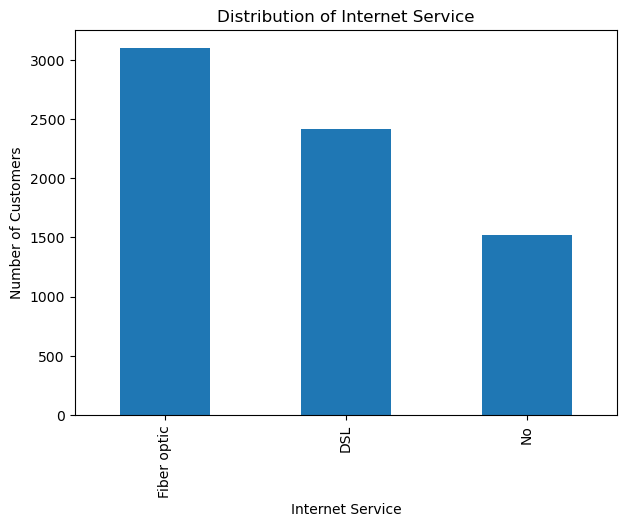

In [24]:
plt.figure(figsize=(7, 5))

df["InternetService"].value_counts().plot(kind="bar")

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Distribution of Internet Service")
plt.show()

## 6.2 Tenure Distribution

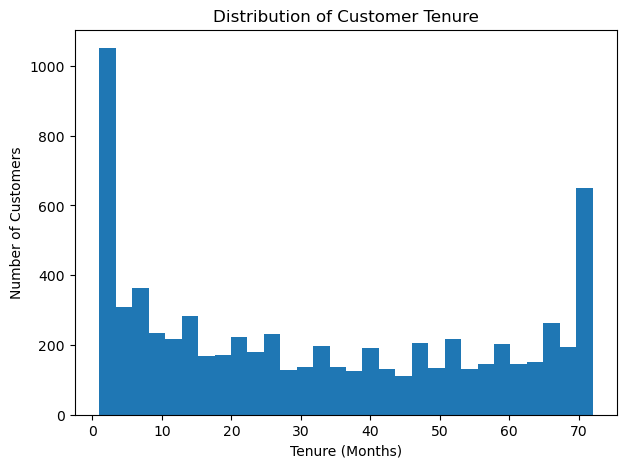

In [25]:
plt.figure(figsize=(7, 5))

plt.hist(df["tenure"], bins=30)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

## 6.3 Tenure vs Monthly Charges

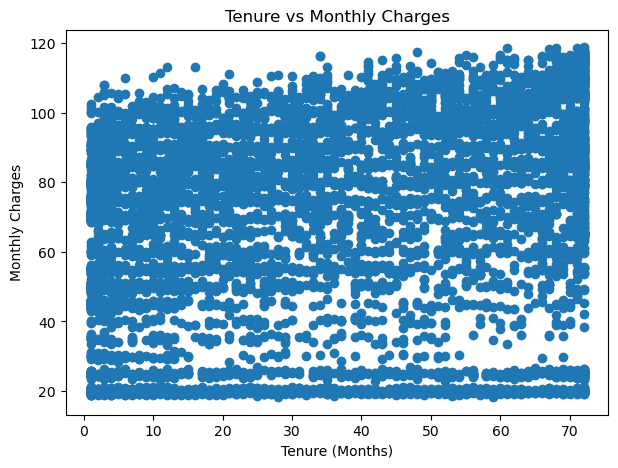

In [26]:
plt.figure(figsize=(7, 5))

plt.scatter(df["tenure"], df["MonthlyCharges"])

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.title("Tenure vs Monthly Charges")
plt.show()

## 6.4 Tenure by Contract

<Figure size 700x500 with 0 Axes>

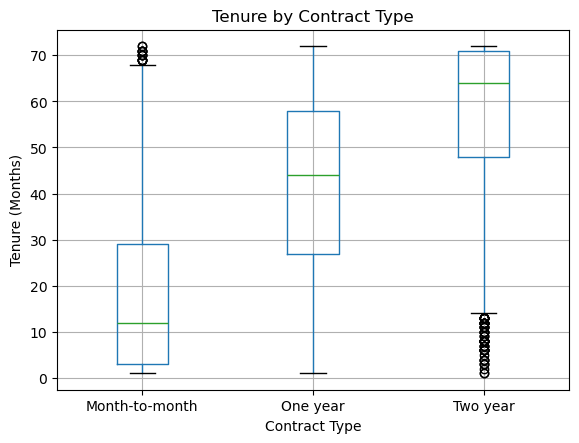

In [27]:
plt.figure(figsize=(7, 5))

df.boxplot(column="tenure", by="Contract")

plt.xlabel("Contract Type")
plt.ylabel("Tenure (Months)")
plt.title("Tenure by Contract Type")
plt.suptitle("")
plt.show()

## 6.5 Outlier Analysis

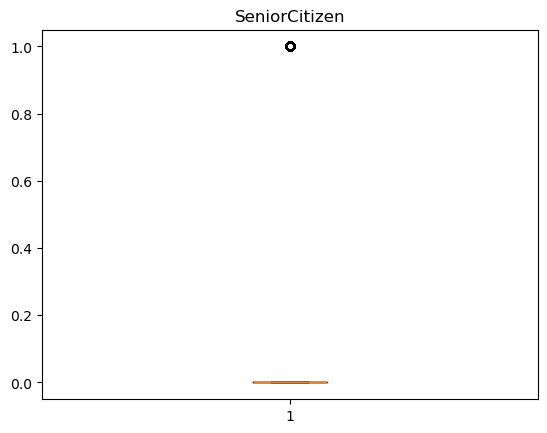

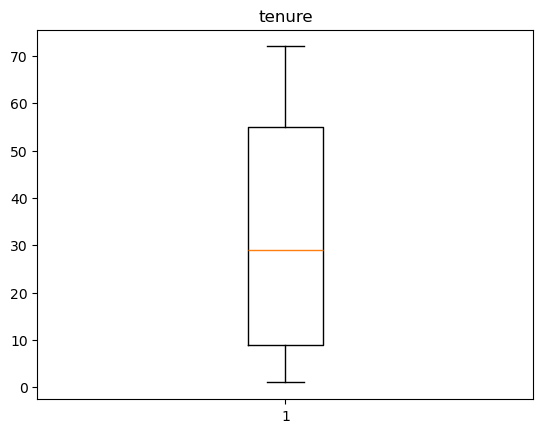

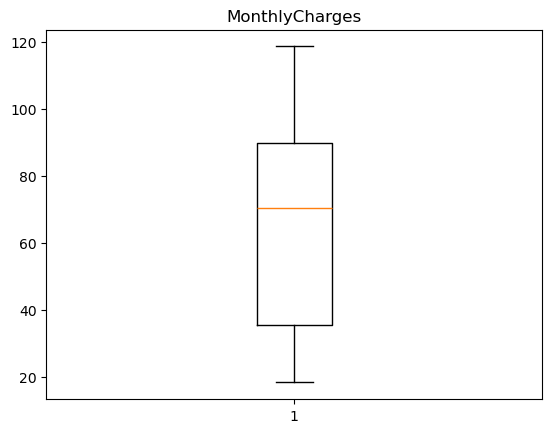

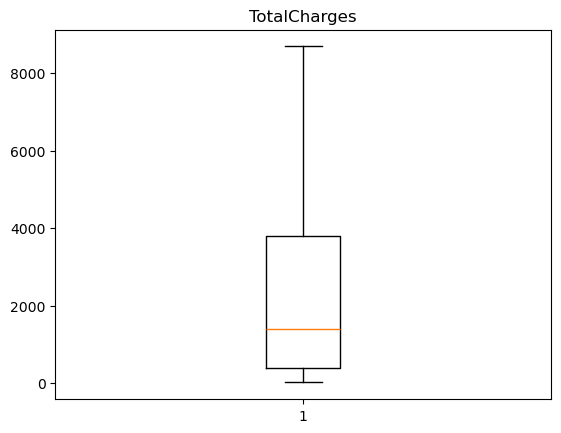

In [28]:
for i in df.columns:
    if df[i].dtypes!="object":
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [29]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


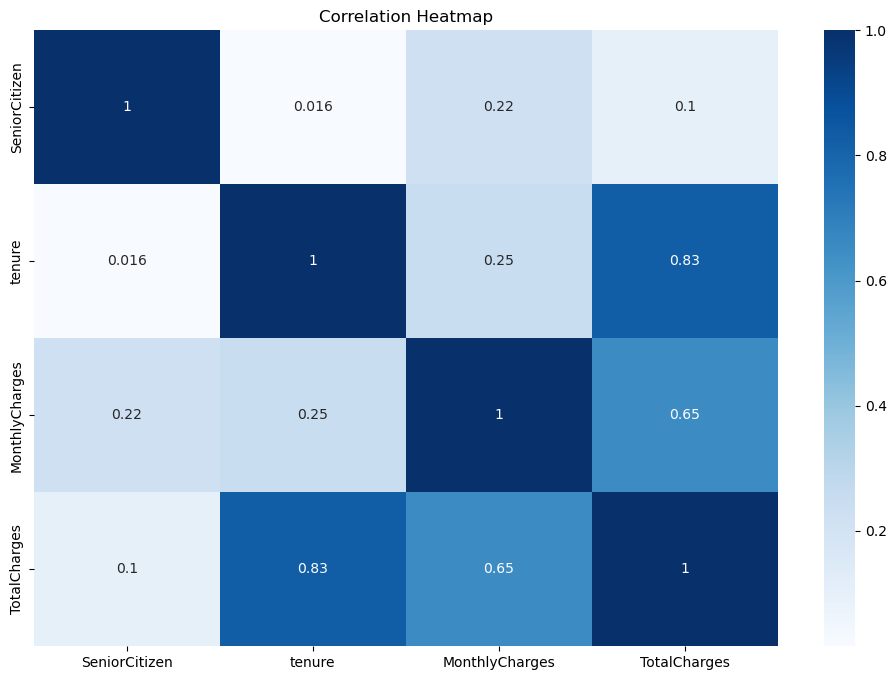

In [30]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

## 7. Linear Regression

### 7.1 Simple Linear Regression

#### 7.1.1 Define Independent and Dependent Variables

In [31]:
# Dependent variable: MonthlyCharges
# Independent variable: tenure

X_linear = df[["tenure"]]
y_linear = df["MonthlyCharges"]

#### 7.1.2 Train-Test Split

In [32]:
# 70:30 train-test split
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_linear,y_linear,test_size=0.30,random_state=42)


#### 7.1.3 Build Linear Regression Model

In [33]:

linear_model = LinearRegression()

linear_model.fit(X_train_linear,y_train_linear)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### 7.1.4 Making Predictions

In [34]:
# Predict
y_pred_linear = linear_model.predict(X_test_linear)

#### 7.1.5 Calculate RMSE

In [35]:
# Calculate rmse
rmse = np.sqrt(mean_squared_error(y_test_linear, y_pred_linear))

print("Coefficient:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

print("RMSE:", rmse)

Coefficient: 0.29407538199066774
Intercept: 55.05621508972834
RMSE: 28.970721349228278


#### 7.1.6 Visualize Linear Regression

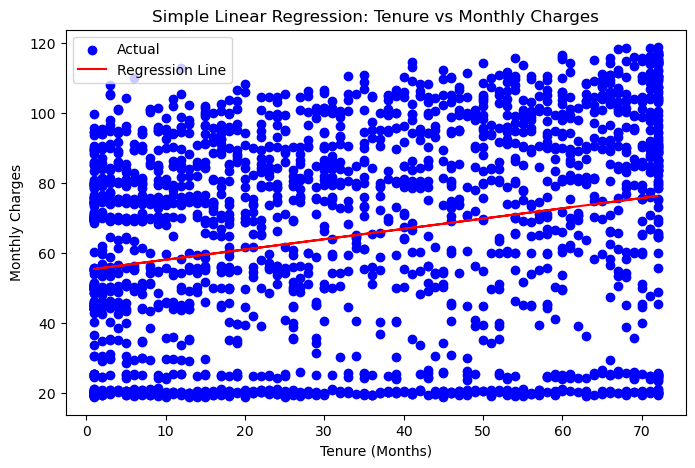

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test_linear["tenure"], y_test_linear,color="blue", label="Actual")
plt.plot(X_test_linear["tenure"], y_pred_linear,color="red", label="Regression Line")

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.title("Simple Linear Regression: Tenure vs Monthly Charges")
plt.legend()
plt.show()

### 7.2 Multiple Linear Regression

#### 7.2.1 Define Independent and Dependent Variables

In [37]:
# Dependent variable: TotalCharges
# Independent variables: tenure and MonthlyCharges

X_multiple = df[["tenure", "MonthlyCharges"]]
y_multiple = df["TotalCharges"]

#### 7.2.2 Train-Test Split

In [38]:
# 70:30 train-test split
X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(X_multiple,y_multiple,test_size=0.30,random_state=42)


#### 7.2.3 Build Linear Regression Model

In [39]:
# Build Multiple Linear Regression model
multiple_linear_model = LinearRegression()

multiple_linear_model.fit(X_train_multiple,y_train_multiple)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### 7.2.4 Making Predictions

In [40]:
# Predict
y_pred_multiple = multiple_linear_model.predict(X_test_multiple)

#### 7.2.5 Calculate RMSE

In [41]:
# Calculate RMSE
rmse_multiple = np.sqrt(mean_squared_error(y_test_multiple, y_pred_multiple))

print("Coefficient:", multiple_linear_model.coef_[0])
print("Intercept:", multiple_linear_model.intercept_)

print("RMSE:", rmse_multiple)

Coefficient: 65.06750257953047
Intercept: -2152.422951192724
RMSE: 720.0287258510504


## 8. Logistic Regression

### 8.1 Simple Logistic Regression

#### 8.1.1 Define Independent and Dependent Variables

In [42]:
# Dependent variable: Churn
# Independent variable: tenure

X_logistic = df[["tenure"]]
y_logistic = df["Churn"].map({"No": 0, "Yes": 1})

#### 8.1.2 Train-Test Split

In [43]:
# 70:30 train-test split

X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(X_logistic,y_logistic,test_size=0.30,random_state=42
)

#### 8.1.3 Build Logistic Regression Model

In [44]:
# Build Logistic Regression model

logistic_model = LogisticRegression()
logistic_model.fit(X_train_logistic,y_train_logistic)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### 8.1.4 Making Predictions

In [45]:
# Predict

y_pred_logistic = logistic_model.predict(X_test_logistic)

#### 8.1.5 Model Evaluation

In [46]:
# Calculate accuracy

accuracy_logistic = accuracy_score(y_test_logistic,y_pred_logistic)

print("Accuracy:", accuracy_logistic)

print("\nClassification Report:")
print(classification_report(y_test_logistic,y_pred_logistic))

Accuracy: 0.7578199052132701

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.95      0.85      1549
           1       0.62      0.22      0.33       561

    accuracy                           0.76      2110
   macro avg       0.70      0.59      0.59      2110
weighted avg       0.73      0.76      0.71      2110



#### 8.1.6 Confusion Matrix

In [47]:
# Create confusion matrix

cm_logistic = confusion_matrix(y_test_logistic,y_pred_logistic)

print(cm_logistic)

[[1474   75]
 [ 436  125]]


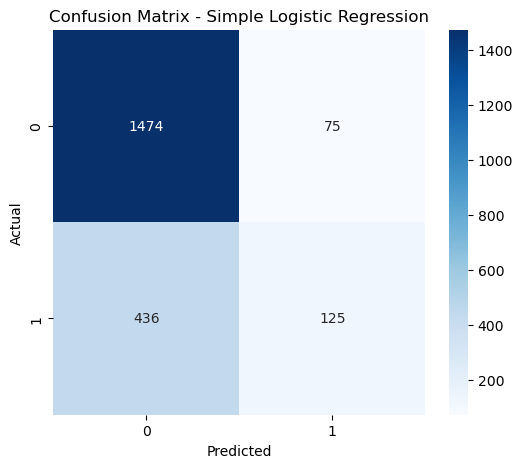

In [48]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(cm_logistic,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Simple Logistic Regression")
plt.show()

### 8.2 Multiple Logistic Regression

#### 8.2.1 Encode Categorical Variables

In [49]:
# Encode categorical variables

le = LabelEncoder()

for col in df.columns:
    if df[col].dtypes == "object":
        df[col] = le.fit_transform(df[col])

df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


#### 8.2.2 Define Independent and Dependent Variables

In [50]:
# Dependent variable: Churn
# Independent variables: All remaining features

X_multiple_logistic = df.drop("Churn", axis=1)
y_multiple_logistic = df["Churn"]

#### 8.2.3 Train-Test Split

In [51]:
# 70:30 train-test split

X_train_multiple_logistic, X_test_multiple_logistic, y_train_multiple_logistic, y_test_multiple_logistic = train_test_split(
    X_multiple_logistic,
    y_multiple_logistic,
    test_size=0.30,
    random_state=42
)

#### 8.2.4 Build Logistic Regression Model

In [52]:
# Build Logistic Regression model

multiple_logistic_model = LogisticRegression(max_iter=1000)

multiple_logistic_model.fit(X_train_multiple_logistic,y_train_multiple_logistic)

C:\Users\nagar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### 8.2.5 Making Predictions

In [53]:
# Predict

y_pred_multiple_logistic = multiple_logistic_model.predict(X_test_multiple_logistic)

#### 8.2.6 Model Evaluation

In [54]:
# Calculate accuracy

accuracy_multiple_logistic = accuracy_score(y_test_multiple_logistic,y_pred_multiple_logistic)

print("Accuracy:", accuracy_multiple_logistic)

print("\nClassification Report:")
print(classification_report(y_test_multiple_logistic,y_pred_multiple_logistic))

Accuracy: 0.7981042654028436

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1549
           1       0.65      0.53      0.58       561

    accuracy                           0.80      2110
   macro avg       0.74      0.71      0.73      2110
weighted avg       0.79      0.80      0.79      2110



### 8.2.7 Confusion Matrix

In [55]:
# Calculate confusion matrix

cm_multiple_logistic = confusion_matrix(y_test_multiple_logistic,y_pred_multiple_logistic)

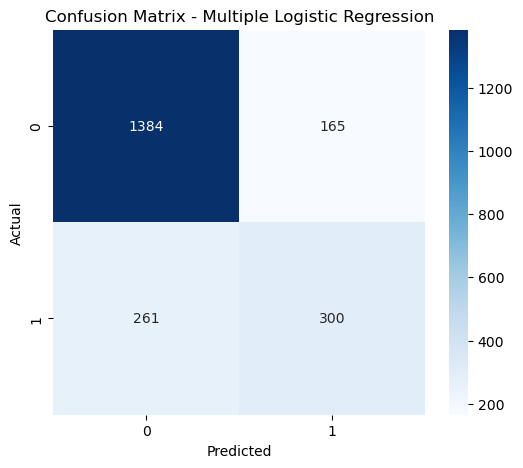

In [56]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(cm_multiple_logistic,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multiple Logistic Regression")
plt.show()

## 9. Decision Tree

### 9.1 Simple Decision Tree

#### 9.1.1 Define Independent and Dependent Variables

In [57]:
# Dependent variable: Churn
# Independent variable: tenure

X_tree = df[["tenure"]]
y_tree = df["Churn"]

#### 9.1.2 Train-Test Split

In [58]:
# 70:30 train-test split

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree,y_tree,test_size=0.30,random_state=42)

#### 9.1.3 Build Decision Tree Model

In [59]:
# Build Decision Tree model

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_tree,y_train_tree)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 9.1.4 Making Predictions

In [60]:
# Predict

y_pred_tree = tree_model.predict(X_test_tree)

#### 9.1.5 Model Evaluation

In [61]:
# Calculate accuracy

accuracy_tree = accuracy_score(y_test_tree,y_pred_tree)

print("Accuracy:", accuracy_tree)

print("\nClassification Report:")
print(classification_report(y_test_tree,y_pred_tree))

Accuracy: 0.7530805687203791

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.84      1549
           1       0.56      0.32      0.41       561

    accuracy                           0.75      2110
   macro avg       0.67      0.61      0.63      2110
weighted avg       0.73      0.75      0.73      2110



#### 9.1.6 Confusion Matrix

In [62]:
# Calculate confusion matrix

cm_tree = confusion_matrix(y_test_tree,y_pred_tree)

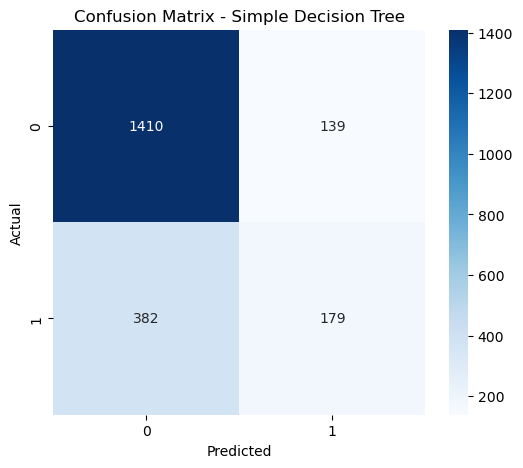

In [63]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(cm_tree,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Simple Decision Tree")
plt.show()

### 9.2 Multiple Decision Tree

#### 9.2.1 Define Independent and Dependent Variables

In [64]:
# Dependent variable: Churn
# Independent variables: All remaining features

X_multiple_tree = df.drop("Churn", axis=1)
y_multiple_tree = df["Churn"]

#### 9.2.2 Train-Test Split

In [65]:
# 70:30 train-test split

X_train_multiple_tree, X_test_multiple_tree, y_train_multiple_tree, y_test_multiple_tree = train_test_split(
    X_multiple_tree,
    y_multiple_tree,
    test_size=0.30,
    random_state=42
)

#### 9.2.3 Build Decision Tree Model

In [66]:
# Build Decision Tree model

multiple_tree_model = DecisionTreeClassifier(random_state=42)

multiple_tree_model.fit(X_train_multiple_tree,y_train_multiple_tree)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 9.2.4 Making Predictions

In [67]:
# Predict

y_pred_multiple_tree = multiple_tree_model.predict(X_test_multiple_tree)

#### 9.2.5 Model Evaluation

In [68]:
# Calculate accuracy

accuracy_multiple_tree = accuracy_score(y_test_multiple_tree,y_pred_multiple_tree)

print("Accuracy:", accuracy_multiple_tree)

print("\nClassification Report:")
print(classification_report(y_test_multiple_tree,y_pred_multiple_tree))

Accuracy: 0.7127962085308057

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1549
           1       0.46      0.49      0.48       561

    accuracy                           0.71      2110
   macro avg       0.64      0.64      0.64      2110
weighted avg       0.72      0.71      0.72      2110



#### 9.2.6 Confusion Matrix

In [69]:
# Calculate confusion matrix

cm_multiple_tree = confusion_matrix(y_test_multiple_tree,y_pred_multiple_tree)

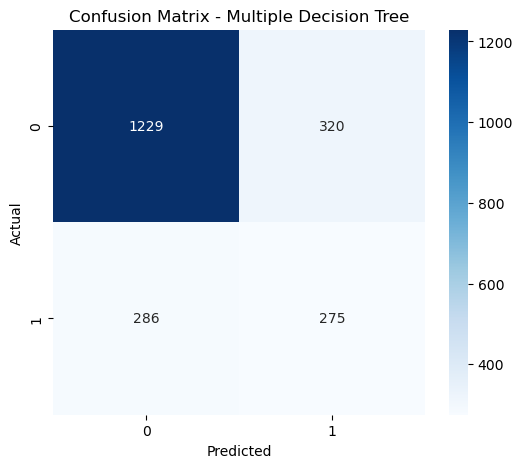

In [70]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(cm_multiple_tree,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multiple Decision Tree")
plt.show()

## 10. Random Forest

### 10.1 Simple Random Forest

#### 10.1.1 Define Independent and Dependent Variables

In [71]:
# Dependent variable: Churn
# Independent variable: tenure

X_random_forest = df[["tenure"]]
y_random_forest = df["Churn"]

#### 10.1.2 Train-Test Split

In [72]:
# 70:30 train-test split

X_train_random_forest, X_test_random_forest, y_train_random_forest, y_test_random_forest = train_test_split(
    X_random_forest,
    y_random_forest,
    test_size=0.30,
    random_state=42
)

#### 10.1.3 Build Random Forest Model

In [73]:
# Build Random Forest model

random_forest_model = RandomForestClassifier(random_state=42)

random_forest_model.fit(X_train_random_forest,y_train_random_forest)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 10.1.4 Making Predictions

In [74]:
# Predict

y_pred_random_forest = random_forest_model.predict(X_test_random_forest)

#### 10.1.5 Model Evaluation

In [75]:
# Calculate accuracy

accuracy_random_forest = accuracy_score(y_test_random_forest,y_pred_random_forest)

print("Accuracy:", accuracy_random_forest)

print("\nClassification Report:")
print(classification_report(y_test_random_forest,y_pred_random_forest))

Accuracy: 0.7530805687203791

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.84      1549
           1       0.56      0.32      0.41       561

    accuracy                           0.75      2110
   macro avg       0.67      0.61      0.63      2110
weighted avg       0.73      0.75      0.73      2110



#### 10.1.6 Confusion Matrix

In [76]:
# Calculate confusion matrix

cm_random_forest = confusion_matrix(y_test_random_forest,y_pred_random_forest)

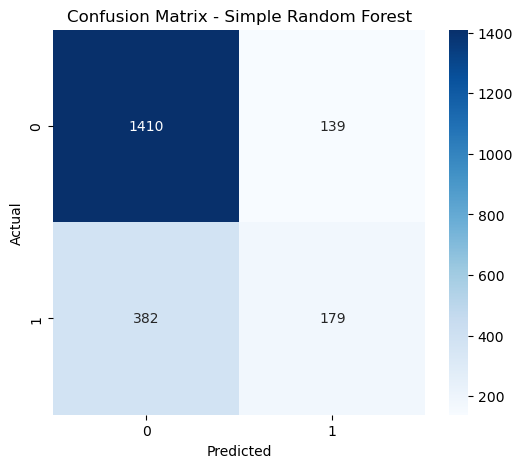

In [77]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(cm_random_forest,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Simple Random Forest")
plt.show()

### 10.2 Multiple Random Forest

#### 10.2.1 Define Independent and Dependent Variables

In [78]:
# Dependent variable: Churn
# Independent variables: All remaining features

X_multiple_random_forest = df.drop("Churn", axis=1)
y_multiple_random_forest = df["Churn"]

#### 10.2.2 Train-Test Split

In [79]:
# 70:30 train-test split

X_train_multiple_random_forest, X_test_multiple_random_forest, y_train_multiple_random_forest, y_test_multiple_random_forest = train_test_split(
    X_multiple_random_forest,
    y_multiple_random_forest,
    test_size=0.30,
    random_state=42
)

#### 10.2.3 Build Random Forest Model

In [80]:
# Build Random Forest model

multiple_random_forest_model = RandomForestClassifier(random_state=42)

multiple_random_forest_model.fit(X_train_multiple_random_forest, y_train_multiple_random_forest)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 10.2.4 Making Predictions

In [81]:
# Predict

y_pred_multiple_random_forest = multiple_random_forest_model.predict(X_test_multiple_random_forest)

#### 10.2.5 Model Evaluation

In [82]:
# Calculate accuracy

accuracy_multiple_random_forest = accuracy_score(y_test_multiple_random_forest,y_pred_multiple_random_forest)

print("Accuracy:", accuracy_multiple_random_forest)

print("\nClassification Report:")
print(classification_report(y_test_multiple_random_forest,y_pred_multiple_random_forest))

Accuracy: 0.7848341232227488

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.62      0.48      0.55       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.78      2110



#### 10.2.6 Confusion Matrix

In [83]:
# Calculate confusion matrix

cm_multiple_random_forest = confusion_matrix(y_test_multiple_random_forest,y_pred_multiple_random_forest)

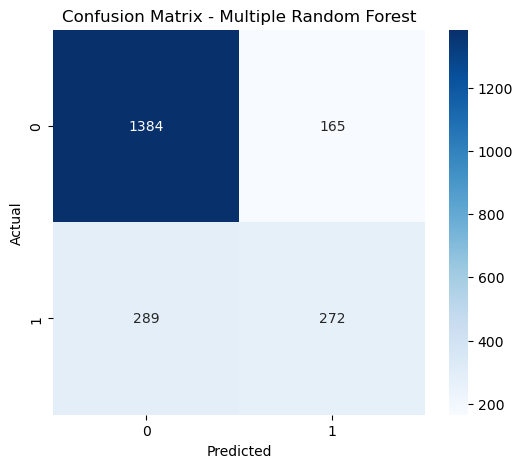

In [84]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(cm_multiple_random_forest,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multiple Random Forest")
plt.show()

## 11. Model Comparison

### 11.1 Compare Model Accuracy

In [85]:
# Compare classification model accuracy

model_comparison = pd.DataFrame({
    "Model": [
        "Simple Logistic Regression",
        "Multiple Logistic Regression",
        "Simple Decision Tree",
        "Multiple Decision Tree",
        "Simple Random Forest",
        "Multiple Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_multiple_logistic,
        accuracy_tree,
        accuracy_multiple_tree,
        accuracy_random_forest,
        accuracy_multiple_random_forest
    ]
})

model_comparison

,Model,Accuracy
0,Simple Logistic Regression,0.757820
1,Multiple Logistic Regression,0.798104
2,Simple Decision Tree,0.753081
3,Multiple Decision Tree,0.712796
4,Simple Random Forest,0.753081
5,Multiple Random Forest,0.784834


In [86]:
# Plot model accuracy

plt.figure(figsize=(10, 5))

plt.bar(
    model_accuracy.keys(),
    model_accuracy.values()
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

NameError: name 'model_accuracy' is not defined

<Figure size 1000x500 with 0 Axes>

## 12. Project Conclusion

This project analyzed customer churn data and developed machine learning models to predict customer churn.

The workflow covered data cleaning, data manipulation, exploratory data analysis, and machine learning model development. Linear Regression was used to analyze relationships between numerical variables, while Logistic Regression, Decision Tree, and Random Forest were used for customer churn classification.

The classification models were evaluated using accuracy, precision, recall, F1-score, and confusion matrices. Model accuracy was also compared across the classification approaches to examine their performance on the test dataset.

Overall, the project demonstrates an end-to-end machine learning workflow, from data preparation and exploratory analysis to model development and evaluation.